# Combine O2 profiles into binned dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import sklearn as skl
import gsw
import cartopy.crs as ccrs
from scipy.interpolate import interp1d
import os
import gc
import resource
import warnings
warnings.filterwarnings('ignore')

In [2]:
# The version information will determine which basin / algorithm will be used to calculate the O2 maps. 
o2_cutoff = 600 # this is an arbitrary defined cut-off value to remove very large O2 input data from Argo
#
selection=[1,3,1,4,6,4]
#
# combine OSD, CTD and PFL equally
#eqave=1
# eqave=0 means the o2 value is weighted by profile count
eqave=0
#
argo_offset = 1.69
#
# maximum analysis depth
max_depth = 5500
#
# hyperbolic tangent correction function
tanhcorr = 1
Ztr   = 150.
Zwidth= 30.
#

### Preprocessing the data
- New in 2025
- Depth is extended to max_depth (determined at the top)
- Training data is including Global mean SST rather than year

In [3]:
# obtain vertical grid
#
en4_dir = f'~/shared/ugit0034/EN4/C14/'
dbase = 'EN4_C14_180x360_'
ds0 = xr.open_dataset(f'{en4_dir}{dbase}196501.nc')
Z = ds0.depth.sel(depth=slice(0, max_depth)).to_numpy()
Nz=np.size(Z)
print(Nz,Z)

102 [0.00e+00 5.00e+00 1.00e+01 1.50e+01 2.00e+01 2.50e+01 3.00e+01 3.50e+01
 4.00e+01 4.50e+01 5.00e+01 5.50e+01 6.00e+01 6.50e+01 7.00e+01 7.50e+01
 8.00e+01 8.50e+01 9.00e+01 9.50e+01 1.00e+02 1.25e+02 1.50e+02 1.75e+02
 2.00e+02 2.25e+02 2.50e+02 2.75e+02 3.00e+02 3.25e+02 3.50e+02 3.75e+02
 4.00e+02 4.25e+02 4.50e+02 4.75e+02 5.00e+02 5.50e+02 6.00e+02 6.50e+02
 7.00e+02 7.50e+02 8.00e+02 8.50e+02 9.00e+02 9.50e+02 1.00e+03 1.05e+03
 1.10e+03 1.15e+03 1.20e+03 1.25e+03 1.30e+03 1.35e+03 1.40e+03 1.45e+03
 1.50e+03 1.55e+03 1.60e+03 1.65e+03 1.70e+03 1.75e+03 1.80e+03 1.85e+03
 1.90e+03 1.95e+03 2.00e+03 2.10e+03 2.20e+03 2.30e+03 2.40e+03 2.50e+03
 2.60e+03 2.70e+03 2.80e+03 2.90e+03 3.00e+03 3.10e+03 3.20e+03 3.30e+03
 3.40e+03 3.50e+03 3.60e+03 3.70e+03 3.80e+03 3.90e+03 4.00e+03 4.10e+03
 4.20e+03 4.30e+03 4.40e+03 4.50e+03 4.60e+03 4.70e+03 4.80e+03 4.90e+03
 5.00e+03 5.10e+03 5.20e+03 5.30e+03 5.40e+03 5.50e+03]


In [4]:
# select analysis period
endyear=2025
# do not change the start year from 1965 (this is when Carpenter 1965 established modern Winkler method)
yrs=np.arange(1965,endyear+1,1)
yrs

array([1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975,
       1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986,
       1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997,
       1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
       2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023, 2024, 2025])

In [5]:
# basin mask
dsm=xr.open_dataset(f'~/shared/ugit0034/WOD18/basin_mask_01.nc')
ma = dsm.basin_mask.isel(depth=0).to_numpy()

In [6]:
# NEW in 2025
# Obtain O2 data from observational dataset
#
#  Argo O2 bias correction can happen here!
#
Nyr=np.size(yrs)
Nt=Nyr*12
mon=["%.2d" % i for i in np.arange(1,13,1)]
dirin='./'
var='Oxygen'
fosd='_OSD_1x1bin_1965-2025'
fctd='_CTD_1x1bin_1971-2025'
fpfl='_PFL_1x1bin_2002-2025'
#
# float32, not float64: this is the single biggest array in the notebook
# (Nt x Nz x 180 x 360) and the raw Oxygen values are float64 on disk, so
# without an explicit dtype here this array alone is ~19GB instead of ~9.5GB.
# Assignments below (o2[...] = ...) downcast the float64 source data
# automatically since the destination array is float32.
o2=np.zeros((Nt,Nz,180,360),dtype=np.float32)
cb=np.zeros((Nt,Nz,180,360),dtype=np.int8)
cc=np.zeros((Nt,Nz,180,360),dtype=np.int8)
cp=np.zeros((Nt,Nz,180,360),dtype=np.int8)
#
ds1=xr.open_dataset(dirin+var+fosd+'.nc').sel(depth=slice(0,max_depth))
ds2=xr.open_dataset(dirin+var+fctd+'.nc').sel(depth=slice(0,max_depth))
ds3=xr.open_dataset(dirin+var+fpfl+'.nc').sel(depth=slice(0,max_depth))
#
if tanhcorr == 1:
    # prepare tanh correction function
    Nt0,Nz0,Ny0,Nx0 = ds1.Oxygen.shape
    f=np.zeros((1,Nz0,1,1))
    f[0,:,0,0] = argo_offset*( np.tanh((ds1.depth-Ztr)/Zwidth) + 1 )/2
    tanh_offset = np.tile(f,[12,1,180,360]).astype('float32')
    
for year in yrs:
    ytmp=year%10
    if ytmp==0:
        print(str(year))
    tr=12*(year-1965)
    timeind0=(year-2005)*12
    # NOTE: selection[1] is an int (see selection=[1,3,1,4,6,4] above). The
    # branches below used to compare it against the strings '1'/'2'/'3', which
    # is always False in Python (int == str never matches) -- so for every
    # year >= 2005 none of these branches ran, and o2 silently stayed at its
    # np.zeros fill value for the entire 2005-2025 Argo era. Fixed by
    # comparing against the actual int values.
    if (year<1987):
        cntb= ds1.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('int')
        o2[tr:(tr+12),:,:,:]=ds1.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('float32')
        cb[tr:(tr+12),:,:,:]=cntb
    elif (year<2005)|(selection[1]==1):
        o2b = ds1.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('float32')
        cntb= ds1.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('int')
        o2c = ds2.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('float32')
        cntc= ds2.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('int')
        o2b=np.where(np.isnan(o2b),0,o2b)
        o2c=np.where(np.isnan(o2c),0,o2c)
        if eqave == 1:
            cntb[cntb>1]=1 # equal weights
            cntc[cntc>1]=1
        o2[tr:(tr+12),:,:,:]=(o2b*cntb+o2c*cntc)/(cntb+cntc)
        cb[tr:(tr+12),:,:,:]=cntb
        cc[tr:(tr+12),:,:,:]=cntc
    elif (selection[1]==2):
        o2b = ds1.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('float32')
        cntb= ds1.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('int')
        o2c = ds2.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('float32')
        cntc= ds2.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('int')
        o2p = ds3.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('float32')
        cntp= ds3.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('int')
        # QC: o2_cutoff removes unphysically large Argo (PFL) readings before
        # they enter the weighted combination; treat them as missing (value
        # and count) rather than clipping so they don't drag the average down.
        argo_bad = o2p > o2_cutoff
        o2p = np.where(argo_bad, np.nan, o2p)
        cntp = np.where(argo_bad, 0, cntp)
        o2b=np.where(np.isnan(o2b),0,o2b)
        o2c=np.where(np.isnan(o2c),0,o2c)
        o2p=np.where(np.isnan(o2p),0,o2p)
        if eqave == 1:
            cntb[cntb>1]=1 # equal weights
            cntc[cntc>1]=1
            cntp[cntp>1]=1
        o2[tr:(tr+12),:,:,:]=(o2b*cntb+o2c*cntc+o2p*cntp)/(cntb+cntc+cntp)
        cb[tr:(tr+12),:,:,:]=cntb
        cc[tr:(tr+12),:,:,:]=cntc
        cp[tr:(tr+12),:,:,:]=cntp
    elif (selection[1]==3):
        o2b = ds1.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('float32')
        cntb= ds1.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('int')
        o2c = ds2.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('float32')
        cntc= ds2.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('int')
        o2p = ds3.Oxygen.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('float32')
        cntp= ds3.sample_count.sel(time=slice(f'{year}-01',f'{year}-12')).values.astype('int')
        # QC: o2_cutoff is checked on the raw sensor value, before the
        # argo_offset bias correction is added; bad points are dropped
        # (value and count) rather than clipped.
        argo_bad = o2p > o2_cutoff
        if tanhcorr == 1:
            o2p = np.where(argo_bad, np.nan, o2p) + tanh_offset
        else:
            o2p = np.where(argo_bad, np.nan, o2p) + argo_offset
        cntp = np.where(argo_bad, 0, cntp)
        o2b=np.where(np.isnan(o2b),0,o2b)
        o2c=np.where(np.isnan(o2c),0,o2c)
        o2p=np.where(np.isnan(o2p),0,o2p)
        if eqave == 1:
            cntb[cntb>1]=1 # equal weights
            cntc[cntc>1]=1
            cntp[cntp>1]=1
        o2[tr:(tr+12),:,:,:]=(o2b*cntb+o2c*cntc+o2p*cntp)/(cntb+cntc+cntp)
        cb[tr:(tr+12),:,:,:]=cntb
        cc[tr:(tr+12),:,:,:]=cntc
        cp[tr:(tr+12),:,:,:]=cntp
    # result quick check
    #tmp=o2[tr:(tr+12),:,:,:].flatten()
    #print(year,np.nanmax(tmp),np.nanmin(tmp))

1970
1980
1990
2000
2010
2020


(5500.0, 0.0)

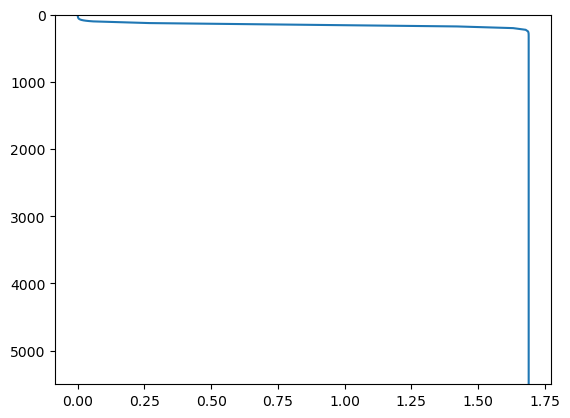

In [8]:
plt.plot(tanh_offset[0,:,0,0],ds1.depth)
plt.ylim(5500,0)

In [9]:
time=ds1.time
lon=ds1.lon
lat=ds1.lat
depth=ds1.depth

In [10]:
da=xr.DataArray(data=o2,name='o2',dims=['time','depth','lat','lon'],\
                coords={'time':time,'depth':depth,'lat':lat,'lon':lon})
ds=da.to_dataset()
ds['sample_count_OSD']=xr.DataArray(data=cb,dims=['time','depth','lat','lon'],\
                coords={'time':time,'depth':depth,'lat':lat,'lon':lon})
ds['sample_count_CTD']=xr.DataArray(data=cc,dims=['time','depth','lat','lon'],\
                coords={'time':time,'depth':depth,'lat':lat,'lon':lon})
ds['sample_count_PFL']=xr.DataArray(data=cp,dims=['time','depth','lat','lon'],\
                coords={'time':time,'depth':depth,'lat':lat,'lon':lon})
ds

<xarray.Dataset> Size: 34GB
Dimensions:           (time: 732, depth: 102, lat: 180, lon: 360)
Coordinates:
  * time              (time) datetime64[ns] 6kB 1965-01-01 ... 2025-12-01
  * depth             (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
  * lat               (lat) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon               (lon) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    o2                (time, depth, lat, lon) float32 19GB nan nan ... nan nan
    sample_count_OSD  (time, depth, lat, lon) int8 5GB 0 0 0 0 0 0 ... 0 0 0 0 0
    sample_count_CTD  (time, depth, lat, lon) int8 5GB 0 0 0 0 0 0 ... 0 0 0 0 0
    sample_count_PFL  (time, depth, lat, lon) int8 5GB 0 0 0 0 0 0 ... 0 0 0 0 0

In [11]:
ds.to_netcdf('Oxygen_NCEI_1x1bin_1965-2025.nc')

In [15]:
o2_monclim = ds.o2.groupby('time.month').mean('time').to_numpy().astype('float32')
mon=np.arange(1,13,1)
da=xr.DataArray(data=o2_monclim,name='o2',dims=['time','depth','lat','lon'],\
                coords={'time':mon,'depth':depth,'lat':lat,'lon':lon})

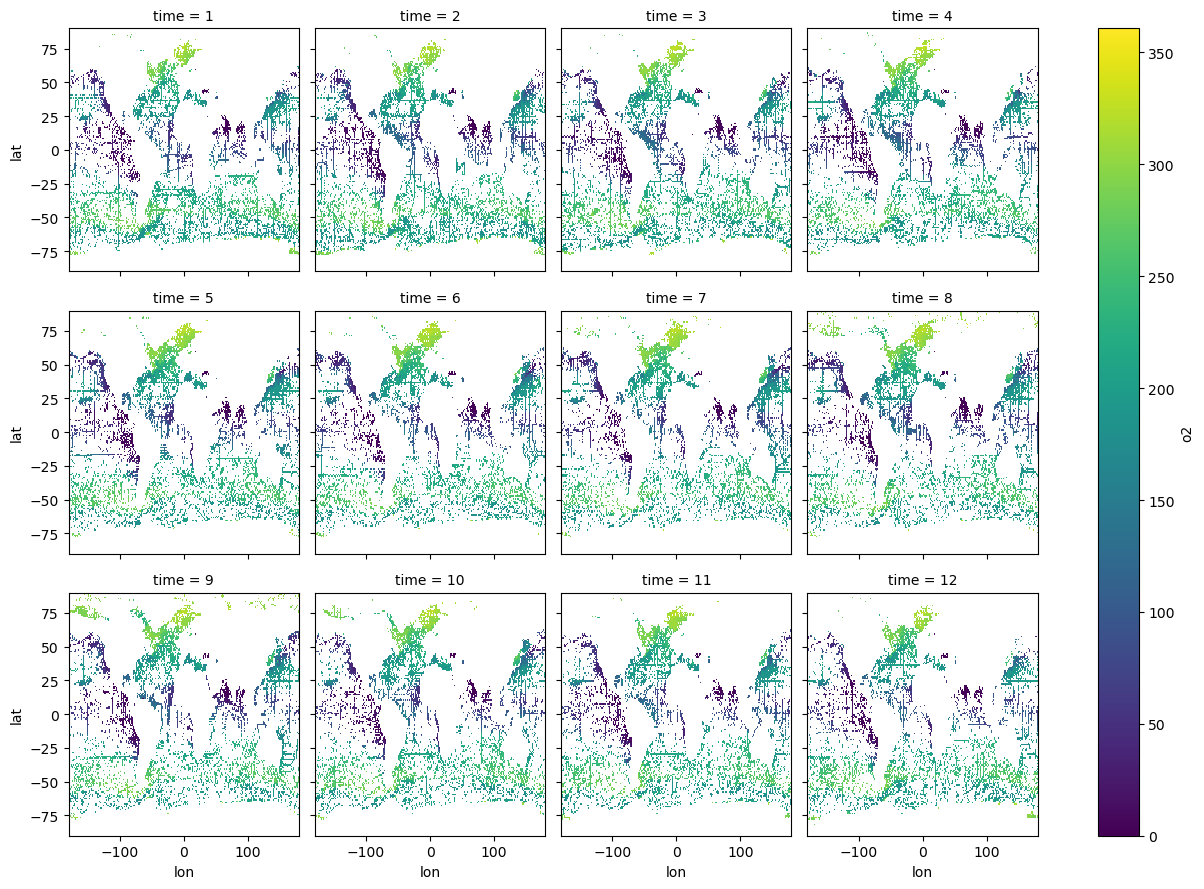

In [16]:
da.sel(depth=400).plot(col='time',col_wrap=4)

In [32]:
o2c0=np.tile(o2_monclim,[3,1,1,1])
o2c =np.zeros_like(o2_monclim)
for n in range(12):
    o2c[n]=np.nanmean(o2c0[(n+12)-1:(n+12)+1,:,:,:],axis=0)

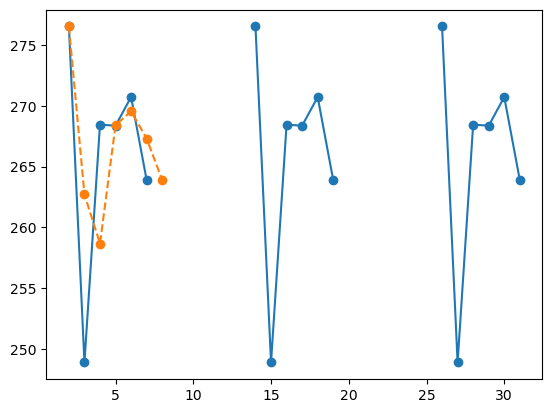

In [39]:
plt.plot(o2c0[:,60,135,160],'o-')
plt.plot(o2c[:,60,135,160],'o--')

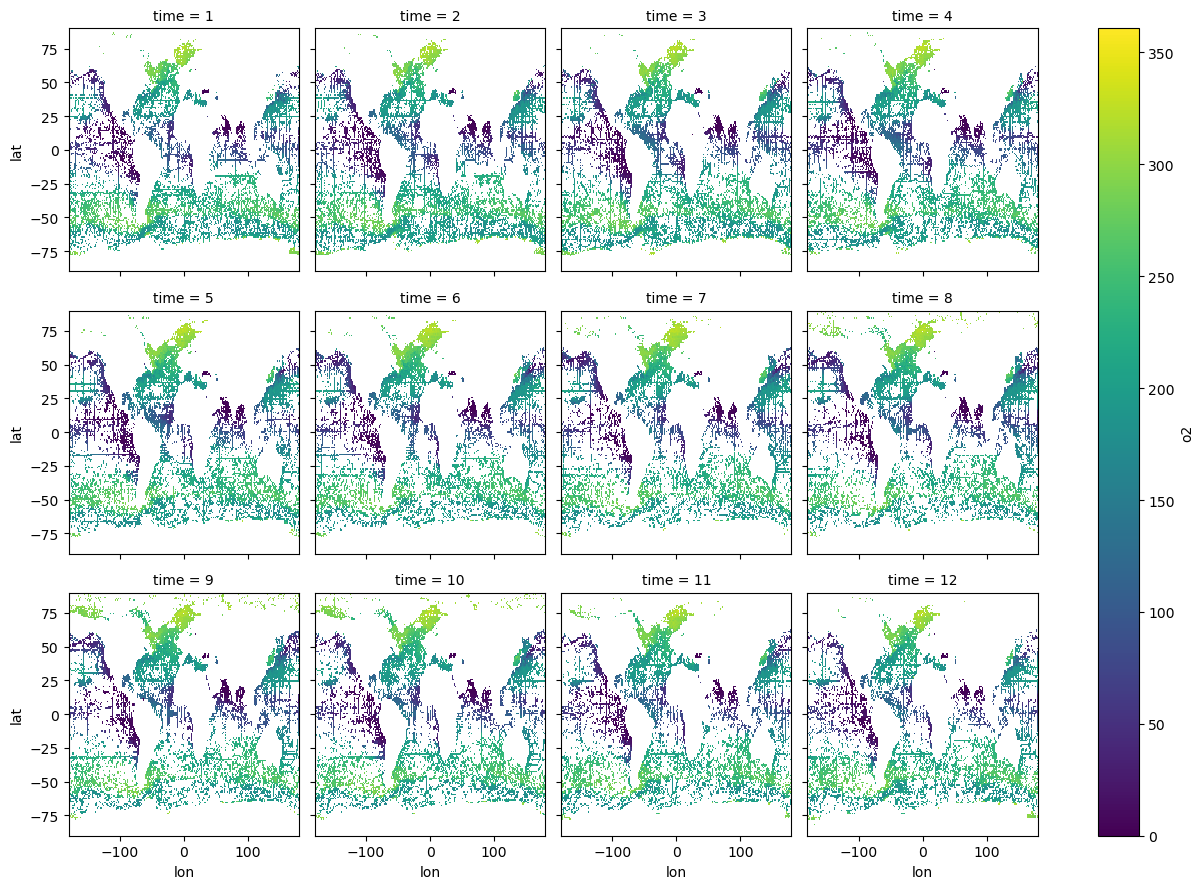

In [35]:
da=xr.DataArray(data=o2c,name='o2',dims=['time','depth','lat','lon'],\
                coords={'time':mon,'depth':depth,'lat':lat,'lon':lon})
da.sel(depth=400).plot(col='time',col_wrap=4)

In [36]:
ds=da.to_dataset()
ds.to_netcdf('Oxygen_NCEI_1x1bin_mon_clim.nc')

In [53]:
ds =xr.open_dataset('Oxygen_NCEI_1x1bin_mon_clim.nc')
lon1=np.arange(0,360,1)+.5
ds1=ds.roll(lon=180,roll_coords=False).assign_coords(lon=lon1)
ds1.to_netcdf('Oxygen_NCEI_1x1bin_mon_clim_lon0to360.nc')

In [41]:
ds0=ds.mean('time')
ds0.to_netcdf('Oxygen_NCEI_1x1bin_ann_clim.nc')

In [54]:
ds =xr.open_dataset('Oxygen_NCEI_1x1bin_ann_clim.nc')
lon1=np.arange(0,360,1)+.5
ds1=ds.roll(lon=180,roll_coords=False).assign_coords(lon=lon1)
ds1.to_netcdf('Oxygen_NCEI_1x1bin_ann_clim_lon0to360.nc')

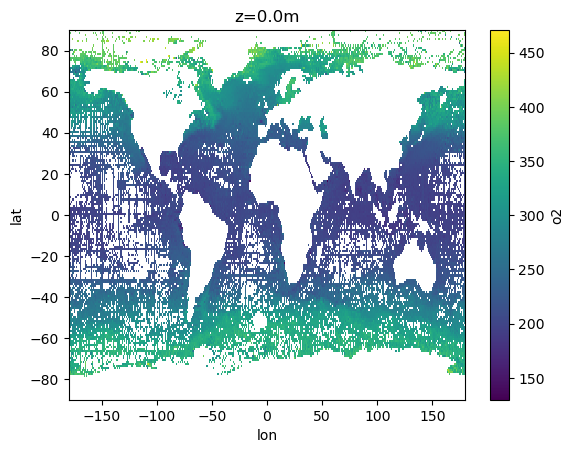

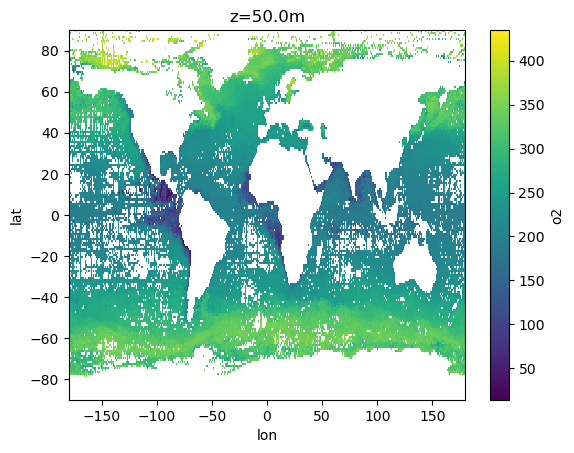

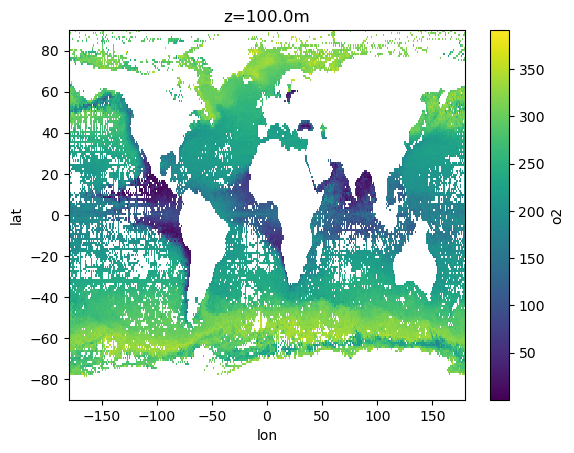

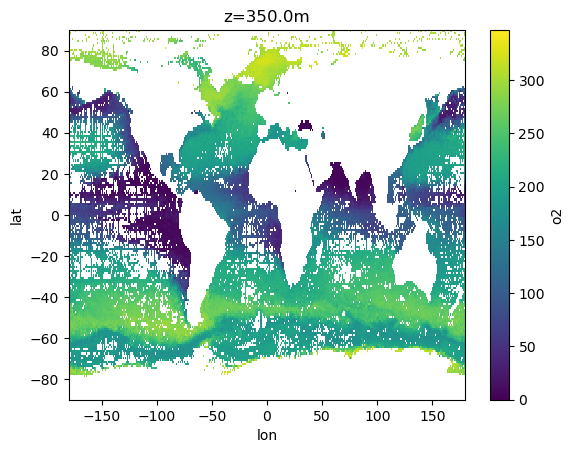

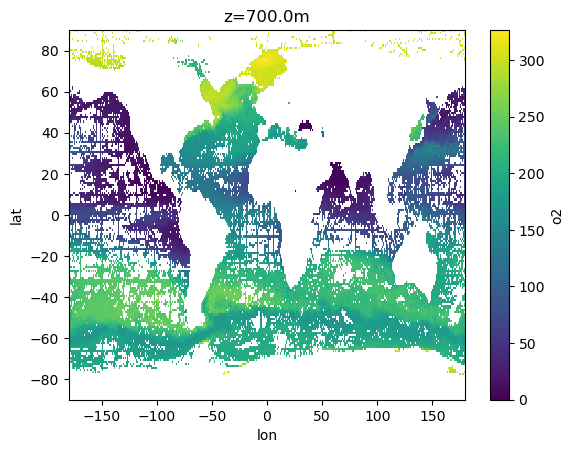

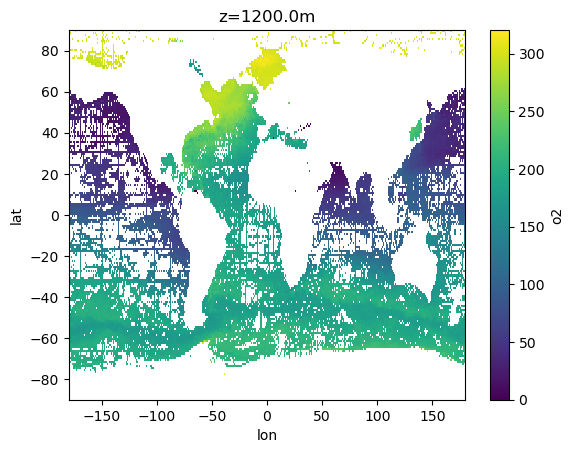

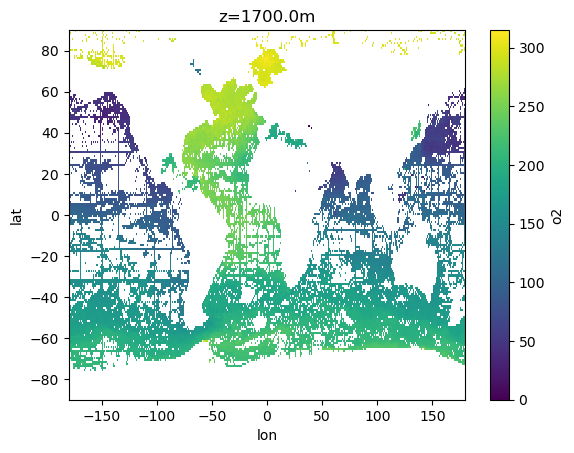

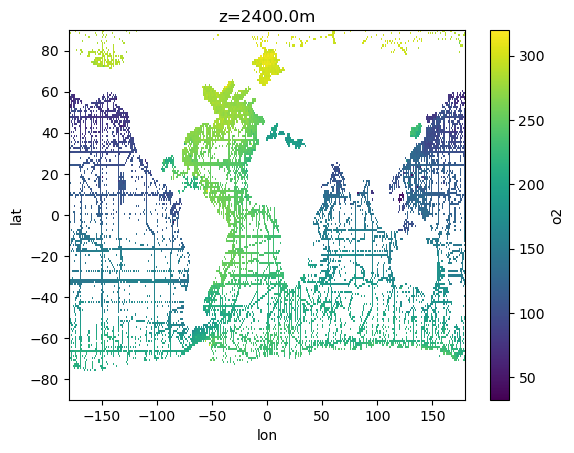

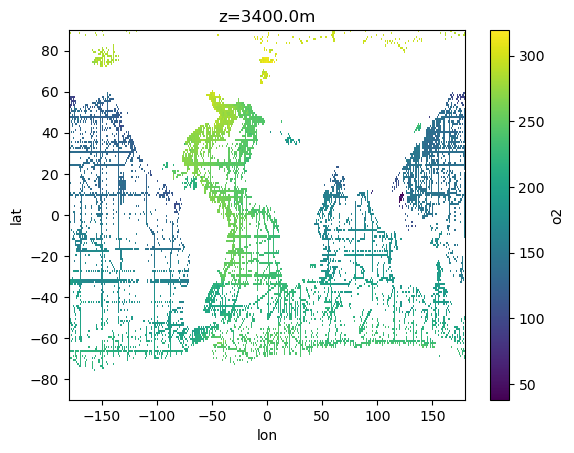

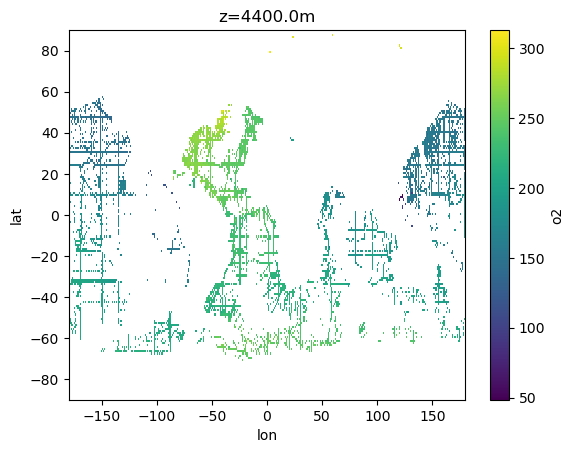

In [44]:
for n in range(10):
    ds0.o2[n*10,:,:].plot()
    plt.title(f'z={ds0.depth[n*10].to_numpy()}m')
    plt.show()